Classification

In [46]:
# Importing numpy and pandas for data manipulation and performing calculation
import numpy as np
import pandas as pd

In [47]:
# Importing dataset
data = pd.read_csv('/content/Accidental_Drug_Related_Deaths.csv')
data

,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,...,Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo
0,05/29/2012,Date of death,37.0,Male,Black,NaN,STAMFORD,FAIRFIELD,NaN,STAMFORD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"STAMFORD, CT\n(41.051924, -73.539475)","STAMFORD, CT\n(41.051924, -73.539475)","CT\n(41.575155, -72.738288)"
1,06/27/2012,Date of death,37.0,Male,White,NaN,NORWICH,NEW LONDON,NaN,NORWICH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"NORWICH, CT\n(41.524304, -72.075821)","NORWICH, CT\n(41.524304, -72.075821)","Norwich, CT\n(41.524304, -72.075821)"
2,03/24/2014,Date of death,28.0,Male,White,NaN,HEBRON,NaN,NaN,HEBRON,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"HEBRON, CT\n(41.658069, -72.366324)","HEBRON, CT\n(41.658069, -72.366324)","Marlborough, CT\n(41.632043, -72.461309)"
3,12/31/2014,Date of death,26.0,Female,White,NaN,BALTIC,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BALTIC, CT\n(41.617221, -72.085031)","CT\n(41.575155, -72.738288)","Baltic, CT\n(41.617221, -72.085031)"
4,01/16/2016,Date of death,41.0,Male,White,NaN,SHELTON,FAIRFIELD,CT,SHELTON,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"SHELTON, CT\n(41.316843, -73.092968)","SHELTON, CT\n(41.316843, -73.092968)","Bridgeport, CT\n(41.179195, -73.189476)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11976,02/28/2023,Date of death,58.0,Female,White,"No, not Spanish/Hispanic/Latino",NEW HAVEN,NEW HAVEN,CT,NEW HAVEN,...,NaN,NaN,NaN,NaN,NaN,N,NaN,"NEW HAVEN, CT\n(41.3082517, -72.9241605)","NEW HAVEN, CT\n(41.3082517, -72.9241605)","CT\n(41.57350273, -72.738305908)"
11977,08/23/2023,Date of death,23.0,Male,White,"Yes, Mexican, Mexican American, Chicano",NEW HAVEN,NEW HAVEN,CT,NEW HAVEN,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"NEW HAVEN, CT\n(41.3082517, -72.9241605)","NEW HAVEN, CT\n(41.3082517, -72.9241605)","CT\n(41.57350273, -72.738305908)"
11978,01/30/2023,Date of death,46.0,Male,White,"No, not Spanish/Hispanic/Latino",DANBURY,FAIRFIELD,CT,DANBURY,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"DANBURY, CT\n(41.393666, -73.451539)","DANBURY, CT\n(41.393666, -73.451539)","CT\n(41.57350273, -72.738305908)"
11979,09/25/2023,Date of death,44.0,Male,White,"Yes, other Spanish/Hispanic/Latino",HARTFORD,HARTFORD,CT,HARTFORD,...,Y,NaN,NaN,NaN,NaN,Y,NaN,"HARTFORD, CT\n(41.765775, -72.673356)","HARTFORD, CT\n(41.765775, -72.673356)","CT\n(41.57350273, -72.738305908)"


In [48]:
# Display number of row and attributes
data.shape

(11981, 48)

In [49]:
# Display information for each attribute
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11981 entries, 0 to 11980
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           11981 non-null  object 
 1   Date Type                      11981 non-null  object 
 2   Age                            11979 non-null  float64
 3   Sex                            11972 non-null  object 
 4   Race                           11924 non-null  object 
 5   Ethnicity                      2565 non-null   object 
 6   Residence City                 11385 non-null  object 
 7   Residence County               10721 non-null  object 
 8   Residence State                9993 non-null   object 
 9   Injury City                    11803 non-null  object 
 10  Injury County                  8647 non-null   object 
 11  Injury State                   8952 non-null   object 
 12  Injury Place                   11623 non-null 

In [50]:
# Display display sum of empty value for each attribute
data.isnull().sum()

,0
Date,0
Date Type,0
Age,2
Sex,9
Race,57
Ethnicity,9416
Residence City,596
Residence County,1260
Residence State,1988
Injury City,178


Data Preprocessing

In [51]:
# Drop irrelevant data attribute or not do present must meaningful result
data.drop(['Other Significant Conditions ', 'Ethnicity', 'Location if Other', 'Heroin death certificate (DC)',
           'Heroin/Morph/Codeine', 'Manner of Death', 'Date Type', 'Other'], axis=1, inplace=True)

In [52]:
# Replace values other than 'Male' and 'Female' with an empty string
data.loc[~data['Sex'].isin(['Male', 'Female']), 'Sex'] = ''

# Calculate the mode while excluding the empty string
mode = data['Sex'][data['Sex'] != ''].mode()[0]

# Fill empty values with the calculated mode
data['Sex'] = data['Sex'].replace('', mode)

# Print the unique values
print(data['Sex'].unique())

['Male' 'Female']


In [53]:
# Make all result Black or African American into Black
data.loc[data['Race'].isin(['Black', 'Black or African American']), 'Race'] = 'Black'

# Make all other result into other except for Black and White
data.loc[~data['Race'].isin(['Black', 'White']), 'Race'] = 'Other'

# This is to generlise the race group

In [54]:
# Filling all empty result in attribute 'Age' with median values
data['Age'] = data['Age'].fillna(data['Age'].median())

In [55]:
# Initializing a list of drugs
drugs = ['Heroin', 'Cocaine', 'Fentanyl', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone',
         'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad', 'Meth/Amphetamine',
         'Morphine (Not Heroin)', 'Hydromorphone', 'Fentanyl Analogue',
         'Xylazine', 'Gabapentin', 'Opiate NOS', 'Other Opioid', 'Any Opioid']

# Filling all missing values in drugs
for drug in drugs:
    data[drug] = data[drug].fillna('N')

# Print result for 'Cocaine'
data['Cocaine']

,Cocaine
0,Y
1,N
2,N
3,N
4,N
...,...
11976,Y
11977,N
11978,N
11979,Y


In [56]:
# For all drug in variable 'drugs', print all unique value for each drugs
for drug in drugs:
   unique_values = data[drug].unique()
   print(f"Unique values for '{drug}': {unique_values}")

Unique values for 'Heroin': ['N' 'Y']
Unique values for 'Cocaine': ['Y' 'N']
Unique values for 'Fentanyl': ['N' 'Y' 'Y POPS' 'Y (PTCH)']
Unique values for 'Oxycodone': ['N' 'Y']
Unique values for 'Oxymorphone': ['N' 'Y']
Unique values for 'Ethanol': ['N' 'Y' 'P']
Unique values for 'Hydrocodone': ['N' 'Y']
Unique values for 'Benzodiazepine': ['N' 'Y']
Unique values for 'Methadone': ['N' 'Y']
Unique values for 'Amphet': ['N' 'Y']
Unique values for 'Tramad': ['N' 'Y']
Unique values for 'Meth/Amphetamine': ['N' 'Y']
Unique values for 'Morphine (Not Heroin)': ['N' 'Y' 'NO RX BUT STRAWS' 'STOLE MEDS' 'PCP NEG']
Unique values for 'Hydromorphone': ['N' 'Y']
Unique values for 'Fentanyl Analogue': ['N' 'Y']
Unique values for 'Xylazine': ['N' 'Y']
Unique values for 'Gabapentin': ['N' 'Y' 'y']
Unique values for 'Opiate NOS': ['N' 'Y']
Unique values for 'Other Opioid': ['N' 'Y' 'PCP' 'Bupren' 'Codeine' 'MDMA' 'Buprenorphine' 'Difluro'
 'MDMA, Buprenorphine' 'ketamine' 'Mitragynine' 'pcp' 'DiFluoro'

In [57]:
# Replacing unique value into only 'Y' or 'N'

for drug in drugs:
    # Replace 'y' with 'Y', for proper generalising the results
    data[drug] = data[drug].replace('y', 'Y')

    # Replace values expect for 'Other Opioid' that is not 'Y' or 'N' with 'N'
    if drug != 'Other Opioid':
        data.loc[~data[drug].isin(['Y', 'N']), drug] = 'N'

    # Replace value for 'Other Opioid' that is not 'Y' or 'N' with 'Y'
    if drug == 'Other Opioid':
        data.loc[~data[drug].isin(['Y', 'N']), drug] = 'Y'

# Print result for each drug to verify its unique values again
for drug in drugs:
   unique_values = data[drug].unique()
   print(f"Unique values for '{drug}': {unique_values}")


Unique values for 'Heroin': ['N' 'Y']
Unique values for 'Cocaine': ['Y' 'N']
Unique values for 'Fentanyl': ['N' 'Y']
Unique values for 'Oxycodone': ['N' 'Y']
Unique values for 'Oxymorphone': ['N' 'Y']
Unique values for 'Ethanol': ['N' 'Y']
Unique values for 'Hydrocodone': ['N' 'Y']
Unique values for 'Benzodiazepine': ['N' 'Y']
Unique values for 'Methadone': ['N' 'Y']
Unique values for 'Amphet': ['N' 'Y']
Unique values for 'Tramad': ['N' 'Y']
Unique values for 'Meth/Amphetamine': ['N' 'Y']
Unique values for 'Morphine (Not Heroin)': ['N' 'Y']
Unique values for 'Hydromorphone': ['N' 'Y']
Unique values for 'Fentanyl Analogue': ['N' 'Y']
Unique values for 'Xylazine': ['N' 'Y']
Unique values for 'Gabapentin': ['N' 'Y']
Unique values for 'Opiate NOS': ['N' 'Y']
Unique values for 'Other Opioid': ['N' 'Y']
Unique values for 'Any Opioid': ['N' 'Y']


In [58]:
# Fill in any remaining missing value with median or mode

for col in data.columns:
    if data[col].isnull().any():
        if data[col].dtype == 'object':
            data[col] = data[col].fillna(data[col].mode()[0])
        else:
            data[col] = data[col].fillna(data[col].median())

data.isnull().sum()

,0
Date,0
Age,0
Sex,0
Race,0
Residence City,0
Residence County,0
Residence State,0
Injury City,0
Injury County,0
Injury State,0


In [59]:
# Check for duplicated rows and remove
duplicate_rows = data[data.duplicated()]
print("Duplicated Rows:")
print(duplicate_rows)

data_no_duplicates = data.drop_duplicates()
print("\nDataframe after removing duplicates:")

Duplicated Rows:
Empty DataFrame
Columns: [Date, Age, Sex, Race, Residence City, Residence County, Residence State, Injury City, Injury County, Injury State, Injury Place, Description of Injury, Death City, Death County, Death State, Location, Cause of Death, Heroin, Cocaine, Fentanyl, Fentanyl Analogue, Oxycodone, Oxymorphone, Ethanol, Hydrocodone, Benzodiazepine, Methadone, Meth/Amphetamine, Amphet, Tramad, Hydromorphone, Morphine (Not Heroin), Xylazine, Gabapentin, Opiate NOS, Other Opioid, Any Opioid, ResidenceCityGeo, InjuryCityGeo, DeathCityGeo]
Index: []

[0 rows x 40 columns]

Dataframe after removing duplicates:


In [60]:
# Extract lantitude and longitude from these attribute for its numerical attribute, as they were part of categorical attribute
import re
def extract_lat_lon(geo_column):
    latitudes = []
    longitudes = []

    for value in geo_column:
        match = re.search(r"\(([-\d.]+), ([-\d.]+)\)", str(value))
        if match:
            latitudes.append(float(match.group(1)))
            longitudes.append(float(match.group(2)))
        else:
            latitudes.append(None)
            longitudes.append(None)

    return latitudes, longitudes


data["Residence City_Latitude"], data["Residence City_Longitude"] = extract_lat_lon(data["ResidenceCityGeo"])
data["Injury City_Latitude"], data["Injury City_Longitude"] = extract_lat_lon(data["InjuryCityGeo"])
data["Death City_Latitude"], data["Death City_Longitude"] = extract_lat_lon(data["DeathCityGeo"])

# Dropping these attribute as they are already present
data.drop(columns=["ResidenceCityGeo", "InjuryCityGeo", "DeathCityGeo"], inplace=True)

In [61]:
# Reorder the longitude and latitude attribute to associate with respective attributes
column_order = []
for col in data.columns:
    if col == "Residence City":
        column_order.extend([col, "Residence City_Latitude", "Residence City_Longitude"])
    elif col == "Injury City":
        column_order.extend([col, "Injury City_Latitude", "Injury City_Longitude"])
    elif col == "Death City":
        column_order.extend([col, "Death City_Latitude", "Death City_Longitude"])
    elif col not in ["Residence City_Latitude", "Residence City_Longitude",
                     "Injury City_Latitude", "Injury City_Longitude",
                     "Death City_Latitude", "Death City_Longitude"]:
        column_order.append(col)

data = data[column_order]
data

,Date,Age,Sex,Race,Residence City,Residence City_Latitude,Residence City_Longitude,Residence County,Residence State,Injury City,...,Meth/Amphetamine,Amphet,Tramad,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Other Opioid,Any Opioid
0,05/29/2012,37.0,Male,Black,STAMFORD,41.051924,-73.539475,FAIRFIELD,CT,STAMFORD,...,N,N,N,N,N,N,N,N,N,N
1,06/27/2012,37.0,Male,White,NORWICH,41.524304,-72.075821,NEW LONDON,CT,NORWICH,...,N,N,N,N,N,N,N,N,N,N
2,03/24/2014,28.0,Male,White,HEBRON,41.658069,-72.366324,NEW HAVEN,CT,HEBRON,...,N,N,N,N,N,N,N,N,N,N
3,12/31/2014,26.0,Female,White,BALTIC,41.617221,-72.085031,NEW HAVEN,CT,HARTFORD,...,N,N,N,N,N,N,N,N,N,N
4,01/16/2016,41.0,Male,White,SHELTON,41.316843,-73.092968,FAIRFIELD,CT,SHELTON,...,N,N,N,N,N,N,N,N,N,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11976,02/28/2023,58.0,Female,White,NEW HAVEN,41.308252,-72.924160,NEW HAVEN,CT,NEW HAVEN,...,N,N,N,N,N,N,N,N,N,N
11977,08/23/2023,23.0,Male,White,NEW HAVEN,41.308252,-72.924160,NEW HAVEN,CT,NEW HAVEN,...,N,N,N,N,N,N,N,N,N,Y
11978,01/30/2023,46.0,Male,White,DANBURY,41.393666,-73.451539,FAIRFIELD,CT,DANBURY,...,N,N,N,N,N,N,N,N,N,Y
11979,09/25/2023,44.0,Male,White,HARTFORD,41.765775,-72.673356,HARTFORD,CT,HARTFORD,...,N,N,N,N,N,Y,N,N,N,Y


In [62]:
# Convert drugs into proper naming format
data = data.rename(columns={'Morphine (Not Heroin)': 'Morphine'})


In [63]:
drugs = ['Heroin', 'Cocaine', 'Fentanyl', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad',
         'Morphine', 'Hydromorphone', 'Fentanyl Analogue', 'Meth/Amphetamine', 'Xylazine', 'Gabapentin', 'Opiate NOS', 'Other Opioid', 'Any Opioid']

# For the list of drugs, perform encoding to convert 'Y' to 1 and 'N' into 0, this allows to display result in numerical format
for col in  ['Heroin', 'Cocaine', 'Fentanyl', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad',
         'Morphine', 'Hydromorphone', 'Fentanyl Analogue', 'Meth/Amphetamine', 'Xylazine', 'Gabapentin', 'Opiate NOS', 'Other Opioid', 'Any Opioid']:
             data[col] = data[col].replace({'Y': 1, 'N': 0})


<ipython-input-63-9a2838d3188b>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({'Y': 1, 'N': 0})


Train-Test Split

In [64]:
# Perform categorical encoding for attribute 'Sex' and 'Race'
data = pd.get_dummies(data, columns=['Sex', 'Race'])

In [65]:
# Feature Selection to select attribute to perform classifcation task
features = ["Age", "Residence City_Latitude", "Residence City_Longitude", "Sex_Female", "Sex_Male", "Race_White", "Race_Black", "Race_Other"]
X = data[features]
y = data["Any Opioid"]

In [66]:
# Importing libraries to perform classification tast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [67]:
# ColumnTransformer allow selected attribute to be preprocess, while keeping other attribute not affected
# StandardScaler allow scaling numerical result into between 0 and 1, this allow no attribute of result in dominating the analysis
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["Age", "Residence City_Latitude", "Residence City_Longitude"]),
    ("cat", "passthrough", ["Sex_Female", "Sex_Male", "Race_White", "Race_Black", "Race_Other"])
])

In [68]:
# Performing train-test split with 80/20 splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Performing Classification with Different Algorithm and Evaluation Metrics

In [69]:
# Importing different classification algorithm to perform classificatin task
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Importing evaluation metric to measure performance for each different classfication algorithm
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

In [70]:
# Firstly for Random Forest Algorithm
print("\nTraining Random Forest")

# Pipeline ensure no data leakage occurs
# Classifier is set parameter to perform random forest algorithm
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Feature are split into training and testing after preprocessing
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

# Print performance metric score for Random Forest Algorithms
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("")
print(classification_report(y_test, y_pred))


Training Random Forest
Random Forest Accuracy: 0.6662494785148102
Precision: 0.7439393939393939
Recall: 0.834088335220838
F1-score: 0.7864388681260011

              precision    recall  f1-score   support

           0       0.30      0.20      0.24       631
           1       0.74      0.83      0.79      1766

    accuracy                           0.67      2397
   macro avg       0.52      0.52      0.51      2397
weighted avg       0.63      0.67      0.64      2397



In [71]:
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.6662494785148102


In [72]:
# Second for K-Nearest Neighbors algorithms
print("\nTraining K-Nearest Neighbors")

# Pipeline ensure no data leakage occurs
# Classifier is set parameter to perform K-Nearest Neighbors algorithm
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Feature are split into training and testing after preprocessing
knn_pipeline.fit(X_train, y_train)
y_pred = knn_pipeline.predict(X_test)

# Print performance metric score for Random Forest Algorithms
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("")
print(classification_report(y_test, y_pred))


Training K-Nearest Neighbors
KNN Accuracy: 0.6812682519816438
Precision: 0.7404030710172744
Recall: 0.8737259343148358
F1-score: 0.8015584415584416

              precision    recall  f1-score   support

           0       0.29      0.14      0.19       631
           1       0.74      0.87      0.80      1766

    accuracy                           0.68      2397
   macro avg       0.51      0.51      0.50      2397
weighted avg       0.62      0.68      0.64      2397



In [73]:
KNN_accuracy = accuracy_score(y_test, y_pred)
print(f"K-Nearest Neightbors Accuracy: {KNN_accuracy}")

K-Nearest Neightbors Accuracy: 0.6812682519816438


In [74]:
# Third for Artificial Neural Network algorithms
print("\nTraining Artificial Neural Network")

# Pipeline ensure no data leakage occurs
# Classifier is set parameter to perform Artificial Neural Network algorithms
ann_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam'
    , max_iter=500, random_state=42))
])

# Feature are split into training and testing after preprocessing
ann_pipeline.fit(X_train, y_train)
y_pred = ann_pipeline.predict(X_test)

# Print performance metric score for Artificial Neural Network algorithms
print("ANN Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("")
print(classification_report(y_test, y_pred))


Training Artificial Neural Network
ANN Accuracy: 0.7338339591155612
Precision: 0.7371740958788898
Recall: 0.992638731596829
F1-score: 0.846042471042471

              precision    recall  f1-score   support

           0       0.32      0.01      0.02       631
           1       0.74      0.99      0.85      1766

    accuracy                           0.73      2397
   macro avg       0.53      0.50      0.43      2397
weighted avg       0.63      0.73      0.63      2397



In [75]:
ANN_accuracy = accuracy_score(y_test, y_pred)
print(f"Artificial Neural Network Accuracy: {ANN_accuracy}")

Artificial Neural Network Accuracy: 0.7338339591155612


In [76]:
# Four for Naive Bayes algorithms
print("\nTraining Naive Bayes")

# Pipeline ensure no data leakage occurs
# Classifier is set parameter to perform Naive Bayes algorithms
nb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

# Feature are split into training and testing after preprocessing
nb_pipeline.fit(X_train, y_train)
y_pred = nb_pipeline.predict(X_test)

# Print performance metric score for Naive Bayes algorithms
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("")
print(classification_report(y_test, y_pred))


Training Naive Bayes
Naive Bayes Accuracy: 0.40175219023779724
Precision: 0.754601226993865
Recall: 0.2785956964892412
F1-score: 0.40694789081885857

              precision    recall  f1-score   support

           0       0.27      0.75      0.40       631
           1       0.75      0.28      0.41      1766

    accuracy                           0.40      2397
   macro avg       0.51      0.51      0.40      2397
weighted avg       0.63      0.40      0.40      2397



In [77]:
NB_accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Bayes Accuracy: {NB_accuracy}")

Naive Bayes Accuracy: 0.40175219023779724


Cross Validation

In [78]:
# Import libraries to perform and evaluate cross-validation for using k-fold
from sklearn.model_selection import cross_val_score, KFold

In [79]:
# Initialize models with pipelines represent different alogrithms
models = {
    "Random Forest": rf_pipeline,
    "K-Nearest Neighbors": knn_pipeline,
    "Artificial Neural Network": ann_pipeline,
    "Naive Bayes": nb_pipeline
}

# Parameters to perform cross validation using K-fold method
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for each model
cv_results = {}

# Cross validation will only perform and evaluate using 'accuracy_score'
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='accuracy')

    # Perform mean and standard deviation calculation for accuracy score using K-fold
    mean_accuracy = scores.mean()
    std_dev = scores.std()

    cv_results[name] = mean_accuracy
    print(f"{name}: Mean Accuracy = {mean_accuracy:.4f}, Std Dev = {std_dev:.4f}")

# Store cross-validation results
cv_accuracy_scores = cv_results


Random Forest: Mean Accuracy = 0.6620, Std Dev = 0.0134
K-Nearest Neighbors: Mean Accuracy = 0.6781, Std Dev = 0.0115
Artificial Neural Network: Mean Accuracy = 0.7345, Std Dev = 0.0131
Naive Bayes: Mean Accuracy = 0.3959, Std Dev = 0.0132


In [80]:
# Import libraries to perform and evaluate cross-validation for using stratified K-fold
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [81]:
# Parameters to perform cross validation using Stratified K-fold method
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for each model
cv_results_stratified = {}

# Cross validation will only perform and evaluate using 'accuracy_score'
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')

    # Perform mean and standard deviation calculation for accuracy score using K-fold
    mean_accuracy = scores.mean()
    std_dev = scores.std()

    cv_results_stratified[name] = mean_accuracy  # Save mean accuracy
    print(f"{name} (Stratified CV): Mean Accuracy = {mean_accuracy:.4f}, Std Dev = {std_dev:.4f}")

# Store cross-validation results
cv_accuracy_scores_stratified = cv_results_stratified


Random Forest (Stratified CV): Mean Accuracy = 0.6669, Std Dev = 0.0076
K-Nearest Neighbors (Stratified CV): Mean Accuracy = 0.6857, Std Dev = 0.0064
Artificial Neural Network (Stratified CV): Mean Accuracy = 0.7355, Std Dev = 0.0014
Naive Bayes (Stratified CV): Mean Accuracy = 0.4009, Std Dev = 0.0159


Data Visualisation

In [82]:
# Import libraries for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
# Storing each accuracy score for each model in a dictionary called 'test_accuracies'
test_accuracies = {
    "Random Forest": rf_accuracy,
    "K-Nearest Neighbors": KNN_accuracy,
    "Artificial Neural Network": ANN_accuracy,
    "Naive Bayes": NB_accuracy
}

# Cross validation accuracy score is assign into variable 'accuracies'
cv_accuracies = cv_accuracy_scores

# Convert into data frame to perform data visualisation
accuracy_df = pd.DataFrame({
    "Model": test_accuracies.keys(),
    "Test Accuracy": test_accuracies.values(),
    "Cross-Validation Accuracy": cv_accuracies.values()
})

# Perform melt to allow easier to perform data visualisation and displaying result
accuracy_df = accuracy_df.melt(id_vars=["Model"], var_name="Metric", value_name="Accuracy")

In [84]:
# Display result after melt process
print(accuracy_df)

                       Model                     Metric  Accuracy
0              Random Forest              Test Accuracy  0.666249
1        K-Nearest Neighbors              Test Accuracy  0.681268
2  Artificial Neural Network              Test Accuracy  0.733834
3                Naive Bayes              Test Accuracy  0.401752
4              Random Forest  Cross-Validation Accuracy  0.662039
5        K-Nearest Neighbors  Cross-Validation Accuracy  0.678107
6  Artificial Neural Network  Cross-Validation Accuracy  0.734451
7                Naive Bayes  Cross-Validation Accuracy  0.395871


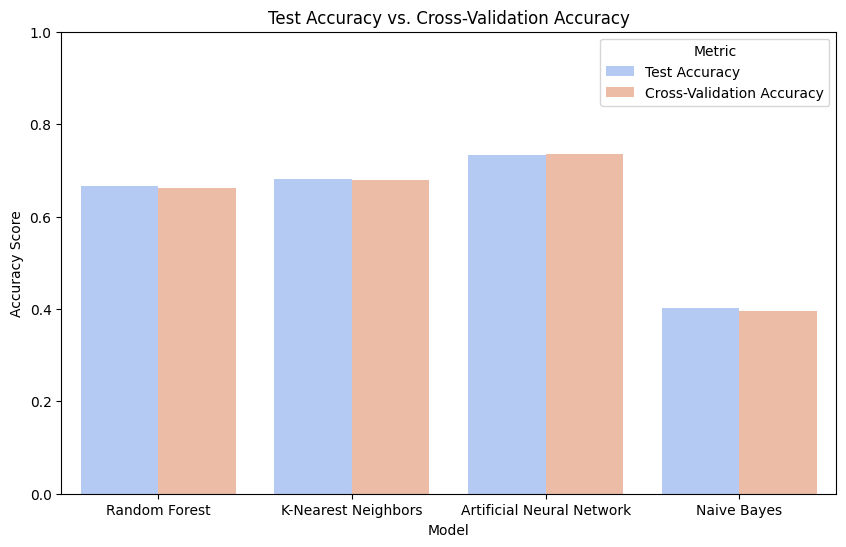

In [85]:
# Plot visualisation for comparison for Test Accuracy and Cross validation accuracy
plt.figure(figsize=(10, 6))

# Plot X with Models name and Y for accuracy result
sns.barplot(x="Model", y="Accuracy", hue="Metric", data=accuracy_df, palette="coolwarm")

# Set Limits into between 0 to 1
plt.ylim(0, 1)
plt.title("Test Accuracy vs. Cross-Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.legend(title="Metric")
plt.show()


<ipython-input-86-e4d7bb6d6a0b>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=model_names, palette="coolwarm")


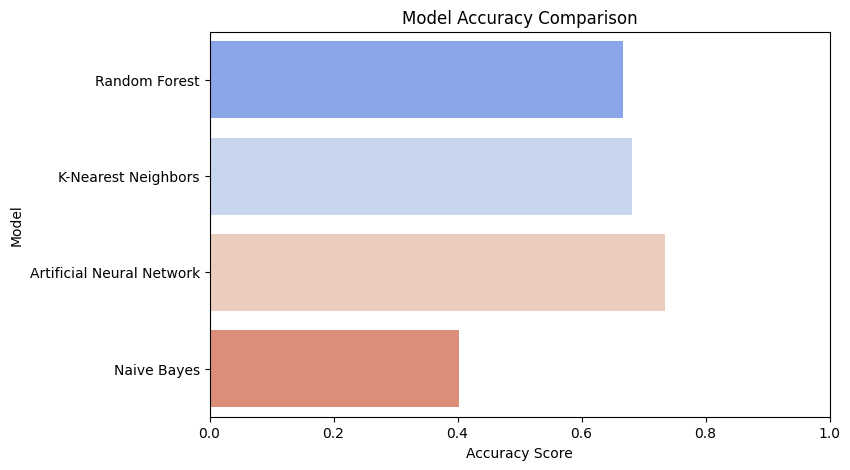

In [86]:
# Convert dictionary to lists for plotting
model_names = list(test_accuracies.keys())
accuracies = list(test_accuracies.values())

# Parameter for plot
plt.figure(figsize=(8, 5))
sns.barplot(x=accuracies, y=model_names, palette="coolwarm")

# Labels and title
plt.xlabel("Accuracy Score")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)

# Show the plot
plt.show()

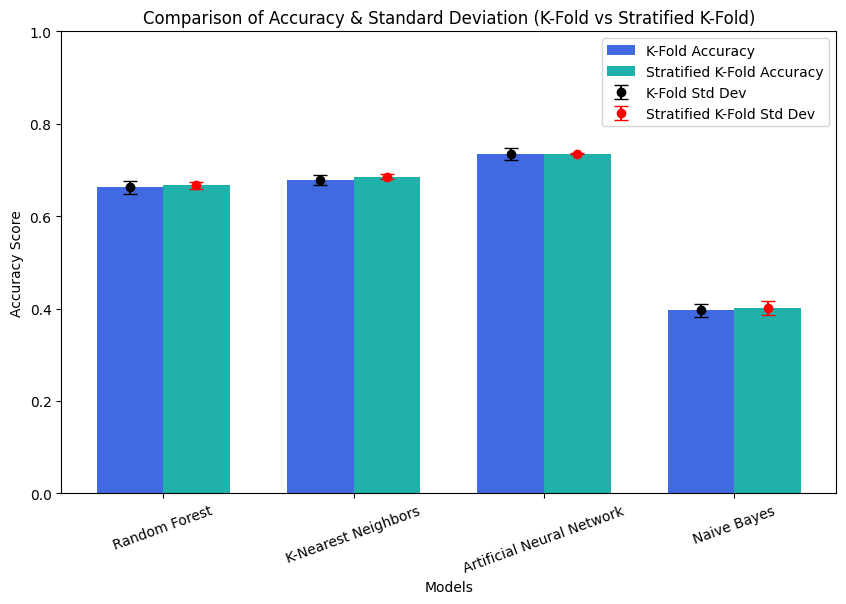

In [87]:
# Convert results into lists
models_list = list(cv_accuracy_scores.keys())

kfold_means = [cv_accuracy_scores[model] for model in models_list]
kfold_stds = [np.std(cross_val_score(models[model], X_train, y_train, cv=kf)) for model in models_list]

stratified_means = [cv_accuracy_scores_stratified[model] for model in models_list]
stratified_stds = [np.std(cross_val_score(models[model], X_train, y_train, cv=skf)) for model in models_list]

# Bar width and x locations
bar_width = 0.35
x = np.arange(len(models_list))

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Accuracy bars
ax.bar(x - bar_width/2, kfold_means, bar_width, label="K-Fold Accuracy", color="royalblue")
ax.bar(x + bar_width/2, stratified_means, bar_width, label="Stratified K-Fold Accuracy", color="lightseagreen")

# Standard deviation bars (error bars)
ax.errorbar(x - bar_width/2, kfold_means, yerr=kfold_stds, fmt="o", color="black", capsize=5, label="K-Fold Std Dev")
ax.errorbar(x + bar_width/2, stratified_means, yerr=stratified_stds, fmt="o", color="red", capsize=5, label="Stratified K-Fold Std Dev")

# Labels & formatting
ax.set_xlabel("Models")
ax.set_ylabel("Accuracy Score")
ax.set_title("Comparison of Accuracy & Standard Deviation (K-Fold vs Stratified K-Fold)")
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20)
ax.set_ylim(0, 1)  # Set limit between 0 and 1 for accuracy
ax.legend()

plt.show()


In [88]:
# Import Libraries for Precision_recall_curve
from sklearn.metrics import precision_recall_curve

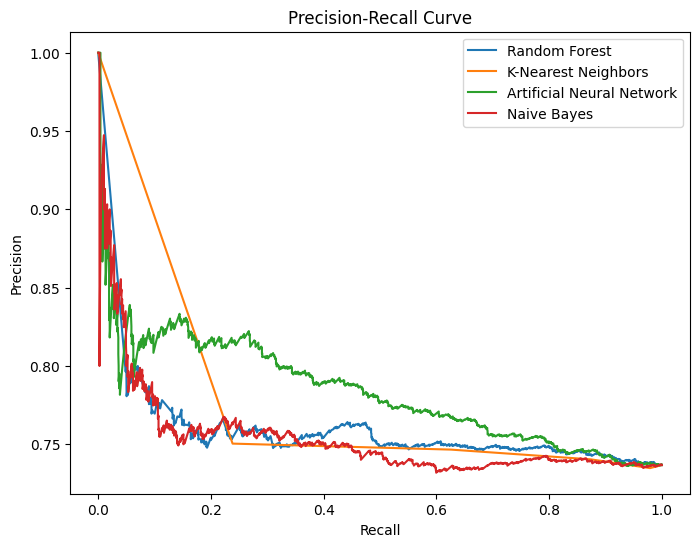

In [89]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [90]:
# Import libraries for ROC curve
from sklearn.metrics import roc_curve, auc

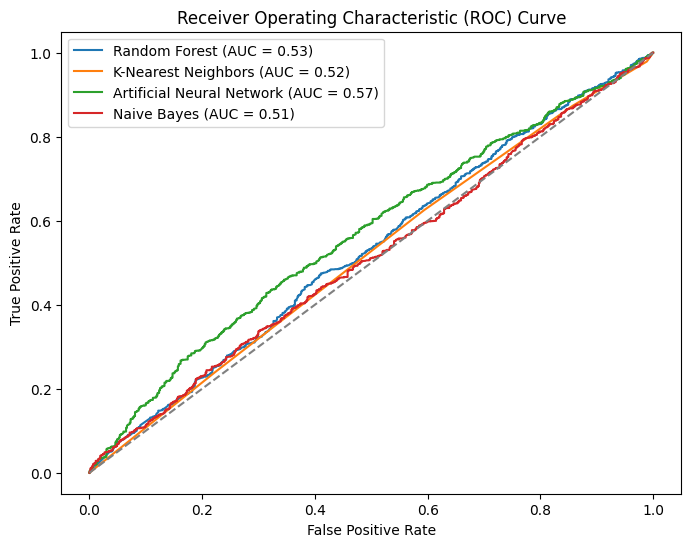

In [91]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot ROC curve
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()
